In [ ]:
#Importing the necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [ ]:
#Check for missing values
df.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


In [ ]:
#Converting float to int (Age)
df['age'] = df['age'].astype(int)
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    int64  
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(2), int64(11)
memory usage: 30.5 KB


Distribution of age among patients with and without death events?

In [ ]:
death_event_yes = df[df['DEATH_EVENT'] == 1]

In [ ]:
death_event_yes['age'].describe()


,age
count,96.000000
mean,65.208333
std,13.217147
min,42.000000
25%,55.000000
50%,65.000000
75%,75.000000
max,95.000000


<Axes: xlabel='age', ylabel='Count'>

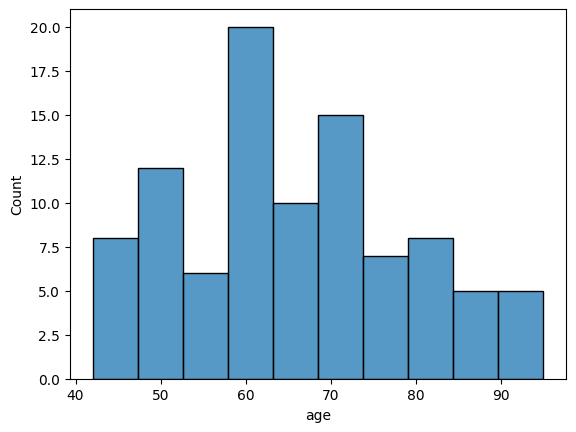

In [ ]:
#Visualize distribution using a histogram
sns.histplot(death_event_yes['age'], bins = 10)

In [ ]:
np.unique(df['DEATH_EVENT'])

array([0, 1])

In [ ]:
death_event_no = df[df['DEATH_EVENT'] == 0]

In [ ]:
death_event_no['age'].describe()

,age
count,203.000000
mean,58.758621
std,10.637402
min,40.000000
25%,50.000000
50%,60.000000
75%,65.000000
max,90.000000


<Axes: xlabel='age', ylabel='Count'>

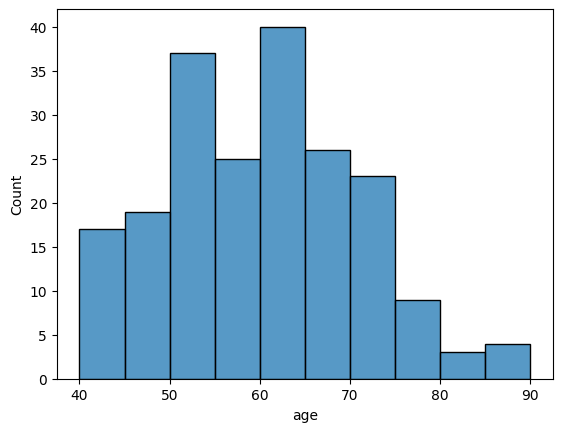

In [ ]:
#Visualize histogram
sns.histplot(death_event_no['age'], bins = 10)

Gender distribution in the dataset

In [ ]:
#percent of each gender
df['sex'].value_counts(normalize = True) # 1 is male, 0 is female

,proportion
sex,
1,0.648829
0,0.351171


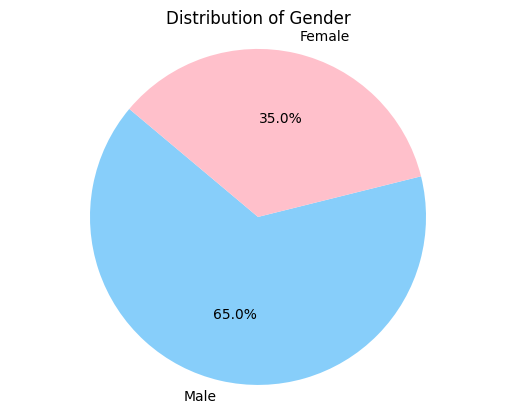

In [ ]:
#Visualize distribution using a pie chart

gender_dict = {'Male': 0.65, 'Female': 0.35}
fig, ax = plt.subplots()
labels = gender_dict.keys()
sizes = gender_dict.values()
colors = ['lightskyblue', 'pink']

ax.pie(sizes, labels = labels, colors = colors, autopct = '%1.1f%%', startangle = 140)
ax.axis('equal')
plt.title('Distribution of Gender')
plt.show()

Does gender impact the likelihood of the death event

In [ ]:
#Group by sex and calculate the death rate
gender_death_rate = df.groupby('sex')['DEATH_EVENT'].value_counts(normalize=True)
gender_death_rate

sex  DEATH_EVENT
0    0              0.676190
     1              0.323810
1    0              0.680412
     1              0.319588
Name: proportion, dtype: float64

Text(0, 0.5, 'Death Rate')

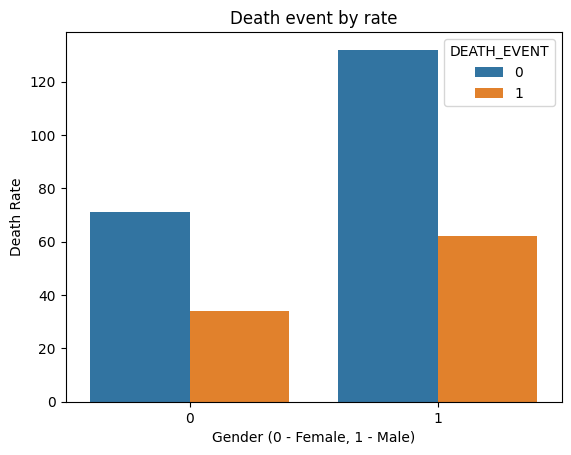

In [ ]:
sns.countplot(x = 'sex', hue = 'DEATH_EVENT', data = df)
plt.title('Death event by rate')
plt.xlabel('Gender (0 - Female, 1 - Male)')
plt.ylabel('Death Rate')

In [ ]:
#if p < 0.05, the difference in death rate between genders is statistically significant
significant_value = 0.05

In [ ]:
from scipy.stats import chi2_contingency
contigency_table = pd.crosstab(df['sex'], df['DEATH_EVENT'])
chi2, p, dof, expected = chi2_contingency(contigency_table)
print('p-value:', p)

if p < 0.05:
  print('The difference in death rate between genders is statistically significant')
else:
  print('The difference in death rate between genders is not statistically significant')

p-value: 1.0
The difference in death rate between genders is not statistically significant


In [ ]:
#average values of serum sodium and creatinine
df[['serum_creatinine', 'serum_sodium']].mean()

,0
serum_creatinine,1.393880
serum_sodium,136.625418


In [ ]:
#grouping by event and finding the average values for creatinine and serum levels
df.groupby('DEATH_EVENT')[['serum_creatinine', 'serum_sodium']].mean()

,serum_creatinine,serum_sodium
DEATH_EVENT,,
0,1.184877,137.216749
1,1.835833,135.375000


Text(0, 0.5, 'Serum creatinine')

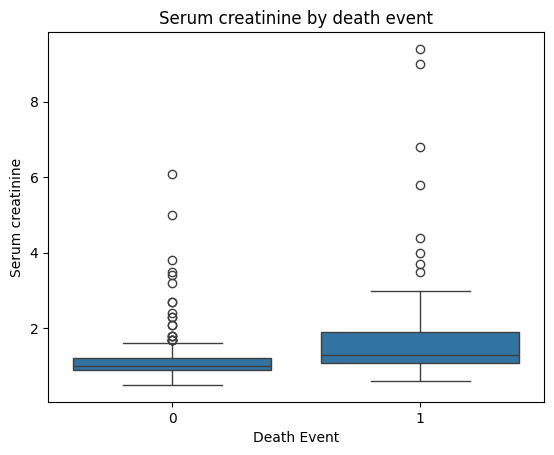

In [ ]:
#Visualize using boxplot
sns.boxplot(x = 'DEATH_EVENT', y = 'serum_creatinine', data = df)
plt.title('Serum creatinine by death event')
plt.xlabel('Death Event')
plt.ylabel('Serum creatinine')

<Axes: xlabel='DEATH_EVENT', ylabel='serum_sodium'>

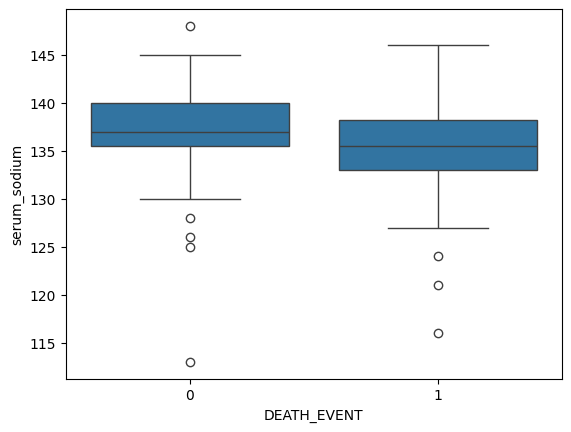

In [ ]:
#box plot for sodium
sns.boxplot(x = 'DEATH_EVENT', y = 'serum_sodium', data = df)

In [ ]:
#Higher average creatinine among the dead might indicate that kidney issues are a risk factors
#lower sodium creatinine among the decreased could suggest electrolyte balance plays a role.

Do patients with high blood pressure have a higher mortality rate?

In [ ]:
bp_death_crosstab = pd.crosstab(df['high_blood_pressure'], df['DEATH_EVENT'],margins = True)
bp_death_crosstab

DEATH_EVENT,0,1,All
high_blood_pressure,,,
0,137,57,194
1,66,39,105
All,203,96,299


In [ ]:
df.groupby('DEATH_EVENT')['high_blood_pressure'].value_counts(normalize = True)

DEATH_EVENT  high_blood_pressure
0            0                      0.674877
             1                      0.325123
1            0                      0.593750
             1                      0.406250
Name: proportion, dtype: float64

In [ ]:
#Statisical test
from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(bp_death_crosstab)
print('p-value:', p)

if p < 0.5:
  print('The difference in death rate between genders is statistically significant')
else:
  print('The difference in death rate between genders is not statistically significant')


p-value: 0.7573258500332782
The difference in death rate between genders is not statistically significant


Is smoking associated with higher chances of death in heart failure patients?

In [ ]:
smoke_death_table = pd.crosstab(df['smoking'], df['DEATH_EVENT'], margins = True)
smoke_death_table

DEATH_EVENT,0,1,All
smoking,,,
0,137,66,203
1,66,30,96
All,203,96,299


In [ ]:
df.groupby('DEATH_EVENT')['smoking'].value_counts(normalize = True)

DEATH_EVENT  smoking
0            0          0.674877
             1          0.325123
1            0          0.687500
             1          0.312500
Name: proportion, dtype: float64

In [ ]:
#Run a chi sqaure test
from scipy.stats import chi2_contingency
contigency = pd.crosstab(df['smoking'], df['DEATH_EVENT'])
chi2, p, dof, expected = chi2_contingency(smoke_death_table)
print('p-value:', p)

if p < 0.5:
  print('The difference in death rate between genders is statistically significant')
else:
  print('The difference in death rate between genders is not statistically significant')

p-value: 0.9997207241170311
The difference in death rate between genders is not statistically significant


What is the average time (follow-up period) for patients who died compared to those who survived?

In [ ]:
df.groupby('DEATH_EVENT')['time'].mean()

,time
DEATH_EVENT,
0,158.339901
1,70.885417


Text(0, 0.5, 'Follow-up period')

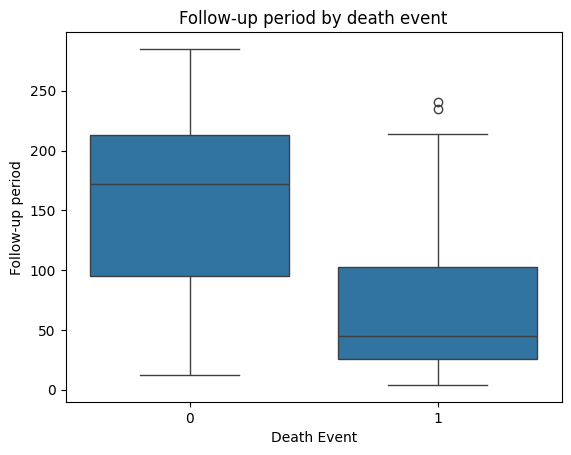

In [ ]:
#Visualize using box plot
sns.boxplot(x = 'DEATH_EVENT', y = 'time', data = df)
plt.title('Follow-up period by death event')
plt.xlabel('Death Event')
plt.ylabel('Follow-up period')